In [ ]:
# Uncomment the next line in Colab or local if needed
!pip install -q pandas numpy nltk torch transformers tqdm matplotlib

import os, math, numpy as np, pandas as pd, nltk, torch, matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Ensure NLTK sentence tokenizer is available
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")
try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    try: nltk.download("punkt_tab")
    except: pass

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
INPUT_CSV = "bsp_speech_dataset.csv"
ID_COL, DATE_COL, TEXT_COL = "index", "Date", "Text"

# Output directory
OUT_DIR = "out_roberta"
os.makedirs(OUT_DIR, exist_ok=True)

# Model
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"  # 3-class sentiment

MAX_LENGTH, BATCH_SIZE = 512, 32
print(f"Input: {INPUT_CSV}\\nOutputs → {OUT_DIR}\\nModel → {MODEL_NAME}")

Input: bsp_summary_sentiment_scores_2.csv\nOutputs → out_roberta\nModel → cardiffnlp/twitter-roberta-base-sentiment-latest


In [ ]:
df = pd.read_csv(INPUT_CSV)
ID_COL, DATE_COL, TEXT_COL = "index", "Date", "Text"
missing = [c for c in [ID_COL, DATE_COL, TEXT_COL] if c not in df.columns]
if missing: raise ValueError(f"Missing columns: {missing}")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
if df[DATE_COL].isna().any():
    bad = df[df[DATE_COL].isna()]
    raise ValueError("Unparseable dates:", bad[[ID_COL, DATE_COL]].head())

print("Rows:", len(df), "| Unique speeches:", df[ID_COL].nunique())
df.head(3)

Rows: 676 | Unique speeches: 676


/tmp/ipython-input-2510514319.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")


,index,Title,Date,Location,Occasion,Speaker,Text,Len,Link,last_name,year
0,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
1,1,Finding Opportunities in a Borderless World,2020-02-28,"El Nido, Palawan",13th Annual FMAP Convention,BSP Governor Benjamin E. Diokno,To the officers and members of the Fund Manage...,2672,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
2,2,Gearing up for the Road Ahead: With Foresight ...,2020-02-27,Sofitel Philippine Plaza Hotel,17th Professional Insurance and Financial Advi...,BSP Governor Benjamin E. Diokno,Officers and members of the Professional Insur...,2922,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020


In [ ]:
df_sent = (df
           .assign(_sents=lambda d: d[TEXT_COL].fillna("").apply(sent_tokenize))
           .explode("_sents")
           .rename(columns={"_sents": "sentence"})
           .reset_index(drop=True))

df_sent["sentence"] = df_sent["sentence"].fillna("").str.strip()
df_sent = df_sent[df_sent["sentence"].str.len() > 0]
print("Total sentences:", len(df_sent), "from", df[ID_COL].nunique(), "speeches")
df_sent.head(6)

Total sentences: 43870 from 676 speeches


,index,Title,Date,Location,Occasion,Speaker,Text,Len,Link,last_name,year,sentence
0,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,"The Manila Times President and CEO, Mr. Dante ..."
1,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,It is a pleasure to be joining today's Busines...
2,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,In line with the conference theme and given th...
3,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,High and volatile inflation is undesirable bec...
4,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,"Until recently, the Philippines is characteriz..."
5,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,"In 2002, onward this trend was reversed."


In [ ]:
df_sent = (df
           .assign(_sents=lambda d: d[TEXT_COL].fillna("").apply(sent_tokenize))
           .explode("_sents")
           .rename(columns={"_sents": "sentence"})
           .reset_index(drop=True))

df_sent["sentence"] = df_sent["sentence"].fillna("").str.strip()
df_sent = df_sent[df_sent["sentence"].str.len() > 0]
print("Total sentences:", len(df_sent), "from", df[ID_COL].nunique(), "speeches")
df_sent.head(6)

Total sentences: 43870 from 676 speeches


,index,Title,Date,Location,Occasion,Speaker,Text,Len,Link,last_name,year,sentence
0,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,"The Manila Times President and CEO, Mr. Dante ..."
1,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,It is a pleasure to be joining today's Busines...
2,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,In line with the conference theme and given th...
3,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,High and volatile inflation is undesirable bec...
4,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,"Until recently, the Philippines is characteriz..."
5,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,"In 2002, onward this trend was reversed."


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.to(device).eval()

id2label = getattr(model.config, "id2label", {0:"negative",1:"neutral",2:"positive"})
print("id2label:", id2label)

Using device: cuda


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


id2label: {0: 'negative', 1: 'neutral', 2: 'positive'}


In [ ]:
def softmax_np(x):
    x -= np.max(x, axis=-1, keepdims=True)
    e = np.exp(x)
    return e/np.sum(e, axis=-1, keepdims=True)

CANON = ["negative","neutral","positive"]
label_texts = {int(k):str(v).lower() for k,v in id2label.items()}
try:
    canon_indices=[ [i for i,l in label_texts.items() if l==n][0] for n in CANON]
except: canon_indices=[0,1,2]

sents=df_sent["sentence"].tolist()
p_neg,p_neu,p_pos=np.zeros(len(sents)),np.zeros(len(sents)),np.zeros(len(sents))

print("Scoring sentences…")
for i in tqdm(range(0,len(sents),BATCH_SIZE)):
    enc=tokenizer(sents[i:i+BATCH_SIZE],padding=True,truncation=True,max_length=MAX_LENGTH,return_tensors="pt").to(device)
    with torch.no_grad(): logits=model(**enc).logits.cpu().numpy()
    probs=softmax_np(logits)[:,canon_indices]
    p_neg[i:i+len(probs)]=probs[:,0]; p_neu[i:i+len(probs)]=probs[:,1]; p_pos[i:i+len(probs)]=probs[:,2]

df_sent["p_neg"],df_sent["p_neu"],df_sent["p_pos"]=p_neg,p_neu,p_pos
df_sent["tone"]=df_sent["p_pos"]-df_sent["p_neg"]
df_sent["label"]=["negative","neutral","positive"][0]
df_sent["label"]=[["negative","neutral","positive"][int(np.argmax(x))] for x in np.stack([p_neg,p_neu,p_pos],1)]

df_sent.head(6)

Scoring sentences…


100%|██████████| 1371/1371 [02:32<00:00,  8.98it/s]


,index,Title,Date,Location,Occasion,Speaker,Text,Len,Link,last_name,year,sentence,p_neg,p_neu,p_pos,tone,label
0,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,"The Manila Times President and CEO, Mr. Dante ...",0.002742,0.134767,0.862491,0.859749,positive
1,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,It is a pleasure to be joining today's Busines...,0.001763,0.033757,0.964480,0.962718,positive
2,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,In line with the conference theme and given th...,0.004792,0.587780,0.407428,0.402636,neutral
3,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,High and volatile inflation is undesirable bec...,0.879208,0.113224,0.007568,-0.871641,negative
4,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,"Until recently, the Philippines is characteriz...",0.482534,0.499208,0.018259,-0.464275,neutral
5,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020,"In 2002, onward this trend was reversed.",0.126188,0.840635,0.033176,-0.093012,neutral


Saved: out_roberta/sentences_scored.csv


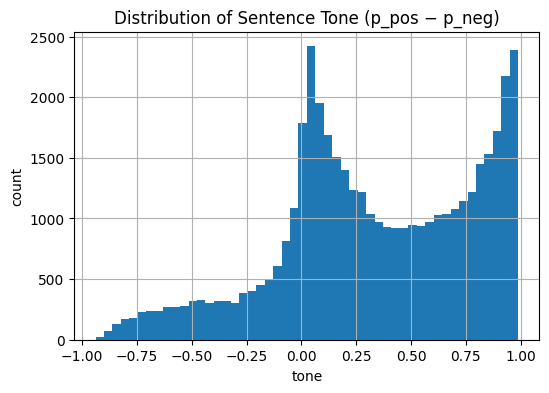

In [ ]:
sent_path=os.path.join(OUT_DIR,"sentences_scored.csv")
df_sent[[ID_COL,DATE_COL,"sentence","p_neg","p_neu","p_pos","tone","label"]].to_csv(sent_path,index=False)
print("Saved:",sent_path)

plt.figure(figsize=(6,4))
df_sent["tone"].hist(bins=50)
plt.title("Distribution of Sentence Tone (p_pos − p_neg)")
plt.xlabel("tone"); plt.ylabel("count"); plt.show()

In [ ]:
def share_over(x,thr=.5): return (x>thr).mean()
def majority_label(x): return x.value_counts().idxmax()

agg=(df_sent.groupby([ID_COL,DATE_COL],as_index=False)
     .agg(tone_mean=("tone","mean"),
          tone_median=("tone","median"),
          pos_share=("p_pos",share_over),
          neg_share=("p_neg",share_over),
          neu_share=("p_neu",share_over),
          n_sent=("sentence","count")))
maj=df_sent.groupby([ID_COL,DATE_COL])["label"].apply(majority_label).reset_index(name="label_majority")
speech_df=agg.merge(maj,on=[ID_COL,DATE_COL],how="left")

speech_path=os.path.join(OUT_DIR,"speeches_aggregated.csv")
speech_df.to_csv(speech_path,index=False)
print("Saved:",speech_path)
speech_df.head(10)

Saved: out_roberta/speeches_aggregated.csv


,index,Date,tone_mean,tone_median,pos_share,neg_share,neu_share,n_sent,label_majority
0,0,2020-03-03,0.285091,0.280469,0.391753,0.082474,0.515464,97,neutral
1,1,2020-02-28,0.455530,0.536039,0.528000,0.024000,0.424000,125,positive
2,2,2020-02-27,0.393128,0.448657,0.476562,0.070312,0.437500,128,positive
3,3,2020-02-06,0.369265,0.417812,0.465909,0.068182,0.465909,88,neutral
4,4,2020-01-31,0.636226,0.740745,0.750000,0.000000,0.200000,20,positive
5,5,2020-01-30,0.365858,0.340388,0.366279,0.029070,0.598837,172,neutral
6,6,2020-01-28,0.513038,0.561176,0.553719,0.024793,0.404959,121,positive
7,7,2020-01-24,0.496346,0.618006,0.585714,0.028571,0.371429,70,positive
8,8,2020-01-21,0.217641,0.083510,0.272727,0.060606,0.666667,33,neutral
9,9,2020-01-09,0.381693,0.468477,0.477941,0.036765,0.470588,136,positive


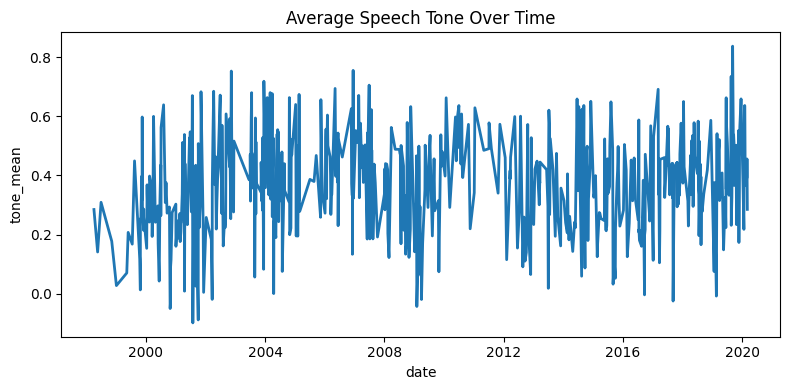

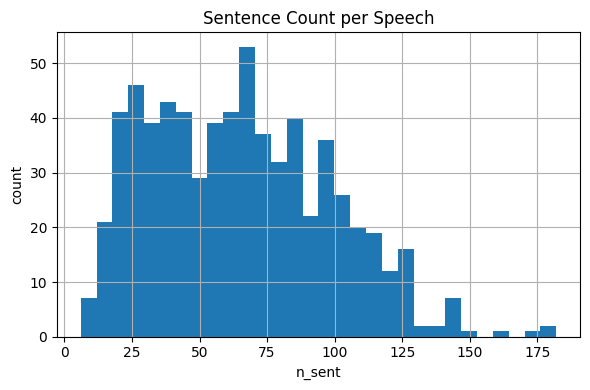

In [ ]:
daily=(speech_df.groupby(DATE_COL,as_index=False)["tone_mean"].mean().sort_values(DATE_COL))
plt.figure(figsize=(8,4))
plt.plot(daily[DATE_COL],daily["tone_mean"],lw=2)
plt.title("Average Speech Tone Over Time")
plt.xlabel("date"); plt.ylabel("tone_mean"); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
speech_df["n_sent"].hist(bins=30)
plt.title("Sentence Count per Speech"); plt.xlabel("n_sent"); plt.ylabel("count")
plt.tight_layout(); plt.show()

/tmp/ipython-input-2589621125.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.set_index(DATE_COL).resample("M").mean()


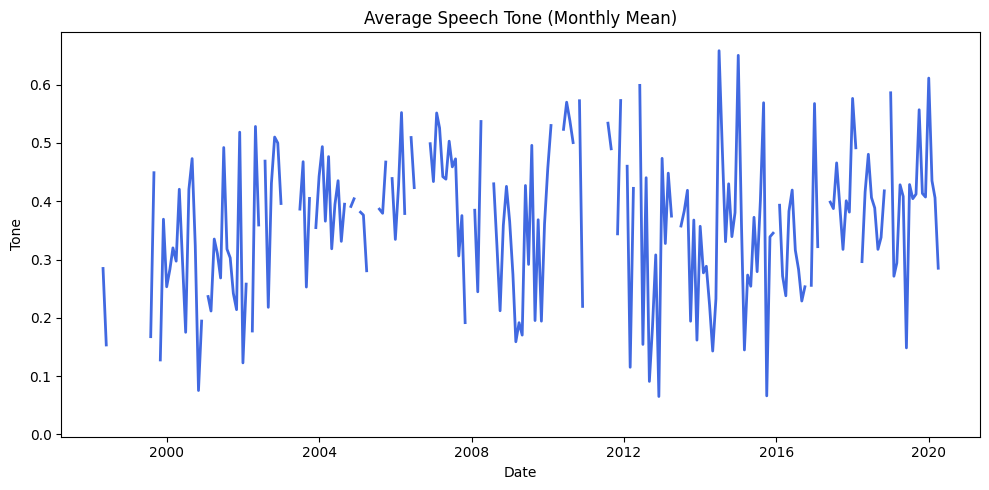

/tmp/ipython-input-2589621125.py:13: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = daily.set_index(DATE_COL).resample("Y").mean()


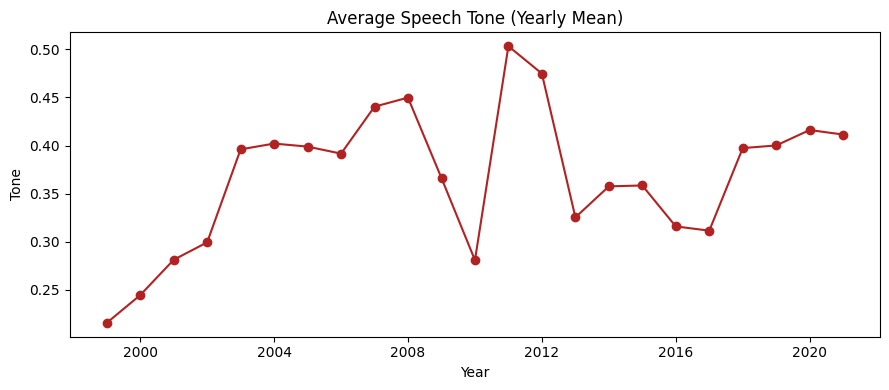

In [ ]:
# Resample to monthly average
monthly = daily.set_index(DATE_COL).resample("M").mean()

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly["tone_mean"], color="royalblue", linewidth=2)
plt.title("Average Speech Tone (Monthly Mean)")
plt.xlabel("Date")
plt.ylabel("Tone")
plt.tight_layout()
plt.show()

# Optional: yearly smoother
yearly = daily.set_index(DATE_COL).resample("Y").mean()
plt.figure(figsize=(9,4))
plt.plot(yearly.index, yearly["tone_mean"], marker='o', color="firebrick")
plt.title("Average Speech Tone (Yearly Mean)")
plt.xlabel("Year")
plt.ylabel("Tone")
plt.tight_layout()
plt.show()

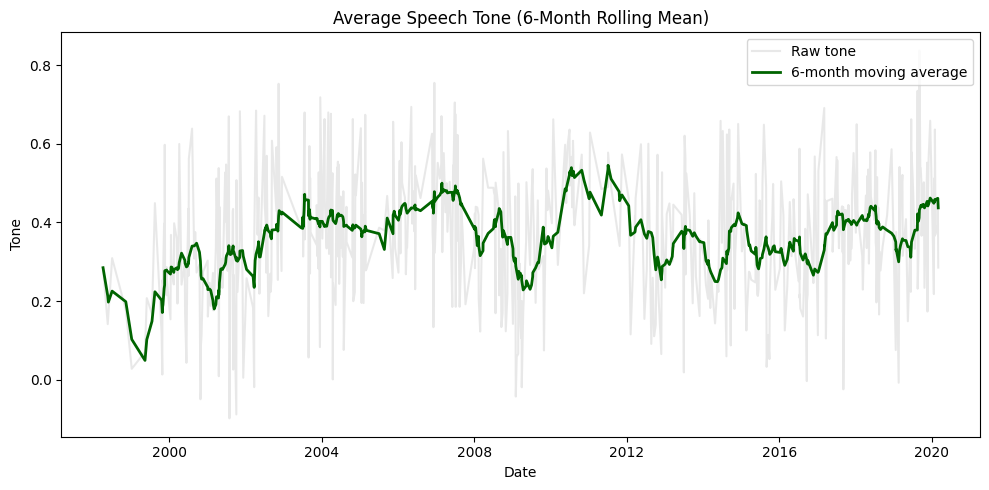

In [ ]:
daily = daily.set_index(DATE_COL).sort_index()
# 180-day (≈6-month) rolling average
daily["tone_6mo"] = daily["tone_mean"].rolling("180D", min_periods=1).mean()

plt.figure(figsize=(10,5))
plt.plot(daily.index, daily["tone_mean"], color="lightgray", alpha=0.5, label="Raw tone")
plt.plot(daily.index, daily["tone_6mo"], color="darkgreen", linewidth=2, label="6-month moving average")
plt.title("Average Speech Tone (6-Month Rolling Mean)")
plt.xlabel("Date")
plt.ylabel("Tone")
plt.legend()
plt.tight_layout()
plt.show()

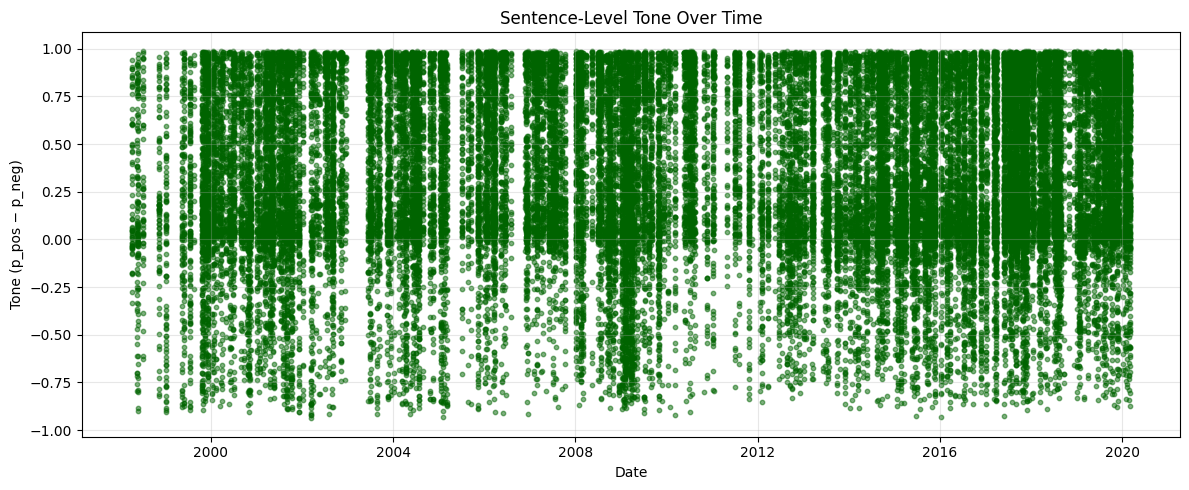

In [ ]:
## VISUALIZATION

# df_sent already contains the 'Date' column as datetime and 'tone' column

plt.figure(figsize=(12,5))
plt.scatter(df_sent["Date"], df_sent["tone"], s=10, alpha=0.5, color="darkgreen")
plt.title("Sentence-Level Tone Over Time")
plt.xlabel("Date")
plt.ylabel("Tone (p_pos − p_neg)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

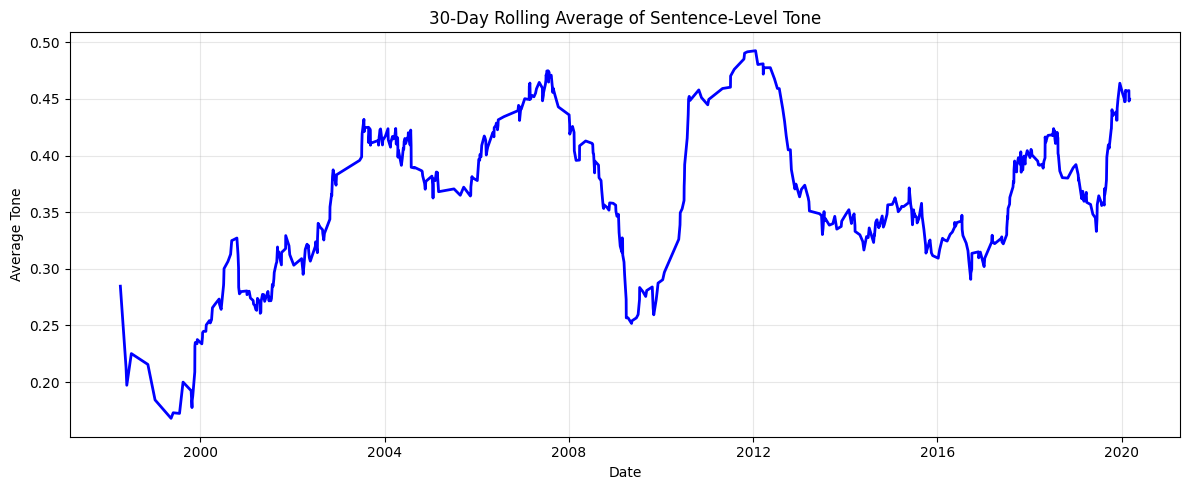

In [ ]:
# Rolling average (30-day window)
daily_mean = df_sent.groupby(DATE_COL)["tone"].mean().rolling(30, min_periods=1).mean()
plt.figure(figsize=(12,5))
plt.plot(daily_mean.index, daily_mean.values, color="blue", linewidth=2)
plt.title("30-Day Rolling Average of Sentence-Level Tone")
plt.xlabel("Date")
plt.ylabel("Average Tone")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()